# Experiment 03 — Verifier Update-Distance Correlation

This experiment tries to see how often hyperplane-hashed Hamming distance agrees with Euclidean distance when choosing an aggregator as the global model. Specifically, it evaluates the extent to which differences in Hamming and Euclidean based selection can cause winner-aggregator disagreement. Tracking the winner agreement is necessary because disagreements eventually lead to a divergence in the federeated learning trajectory.

Unlike the previous controlled synthetic experiments, this one implements the LSHFed setup. This includes 5 ResNet9 Local Trainers training on 2000 samples each from the CIFAR-10 dataset. The Local Trainers are assigned to 2 Aggregators in a round-robin fashion (LT0, LT2, LT4 for AG0, and LT1, LT3 for AG1). In each round, the Local Trainers train on their locally available data samples, and the corresponding Aggregator receives their gradients and aggregates them. The Aggregators then project the combined gradients onto random hyperplanes, which converts the gradients from floating point matrices into hashed binary strings.

The Hamming distance is calculated between the hashed bit strings of the last round's global model (previously chosen Aggregator) and all Aggregators of the current round, and the one with the lowest distance to the global state is selected as the winner. On the other hand, the Euclidean distance is calculated from the original gradients themselves. The winners found by either distance are recorded; however, the Hamming-chosen Aggregator is the one set as the global model, and thus sent back to all the Local Trainers to complete one round of the federated learning process. This means that the objective of the Euclidean distance is to provide insight into winner agreement or disagreement for every round, but the actual trajectory decision is made by the Hamming distance. The discrepancies in candidate selection are reported over 8 federated training rounds.

**Experimental design**

- *Dataset:* CIFAR-10
- *Training subset:* 10,000 randomly sampled examples (seed = 42)
- *Clients:* 5 Local Trainers (LTs), each with 2,000 IID samples
- *Aggregators:* AG0 = LT[0,2,4], AG1 = LT[1,3]
- *Local training:* 1 epoch, SGD (lr=0.01, momentum=0.9)
- *Rounds:* 8
- *LSH projections:* r = 5
- *Comparison:* Each current AG update is compared against the previous round's Hamming-selected benchmark update using both Hamming and Euclidean distance.

Round 0 initializes the benchmark with AG0. Rounds 1-7 produce two candidate comparisons each, yielding 14 observations.

In [ ]:
from pathlib import Path
import copy
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

SEED = 42
DATA_DIR = Path("data")
RESULTS_DIR = Path("results")
FIGURES_DIR = RESULTS_DIR / "figures"
for d in (DATA_DIR, RESULTS_DIR, FIGURES_DIR):
    d.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Improve reproducibility.
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print("PyTorch:", torch.__version__)
print("Working directory:", Path.cwd().resolve())

Device: cuda
PyTorch: 2.11.0+cu128
Working directory: /content


## CIFAR-10 dataset and deterministic client partition

Downloading 10,000 samples from the train set

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = datasets.CIFAR10(root=DATA_DIR, train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root=DATA_DIR, train=False, download=True, transform=transform)

TRAIN_SAMPLES = 10000
rng = np.random.default_rng(SEED)
subset_indices = rng.choice(len(train_dataset), size=TRAIN_SAMPLES, replace=False)
train_subset = Subset(train_dataset, subset_indices.tolist())

print("Full CIFAR-10 training set:", len(train_dataset))
print("Selected training subset:", len(train_subset))

100%|██████████| 170M/170M [16:01<00:00, 177kB/s]


Full CIFAR-10 training set: 50000
Selected training subset: 10000


The Local Trainers each receive 2,000 samples.

The samples are sectioned using a fixed seed for reproducibility.

The batches within the data loader of the 2,000 samples are fixed seeded too.

In [3]:
NUM_LTS = 5
NUM_AGS = 2
BATCH_SIZE = 32

indices = np.array(train_subset.indices)
rng = np.random.default_rng(SEED)
rng.shuffle(indices)
lt_indices = np.array_split(indices, NUM_LTS)

lt_loaders = []
for lt_id, idxs in enumerate(lt_indices):
    lt_dataset = Subset(train_dataset, idxs.tolist())
    generator = torch.Generator().manual_seed(SEED + lt_id)
    loader = DataLoader(
        lt_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=generator,
        num_workers=0, pin_memory=torch.cuda.is_available()
    )
    lt_loaders.append(loader)
    print(f"LT {lt_id}: {len(lt_dataset)} samples, {len(loader)} batches")

LT 0: 2000 samples, 63 batches
LT 1: 2000 samples, 63 batches
LT 2: 2000 samples, 63 batches
LT 3: 2000 samples, 63 batches
LT 4: 2000 samples, 63 batches


## ResNet9 Model
This architecture is defined in the paper's repository. 

This time the model participates in the federeated learning protocol, and each LT model sends its gradients to its corresponding AG to be aggregated. It is the aggregated gradient update that gets projected and hashed. This is different from experiment 01, which had hashed within-model gradients to study their correlation, without running the actual FL pipeline.

In [4]:
def conv_block(in_channels, out_channels, pool=False):
    layers=[nn.Conv2d(in_channels,out_channels,kernel_size=3,padding=1), nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True)]
    if pool: layers.append(nn.MaxPool2d(2))
    return nn.Sequential(*layers)

class CustomModel(nn.Module):
    def __init__(self, in_channels=3, num_classes=10):
        super().__init__()
        self.conv1=conv_block(in_channels,64)
        self.conv2=conv_block(64,128,pool=True)
        self.res1=nn.Sequential(conv_block(128,128),conv_block(128,128))
        self.conv3=conv_block(128,256,pool=True)
        self.conv4=conv_block(256,512,pool=True)
        self.res2=nn.Sequential(conv_block(512,512),conv_block(512,512))
        self.classifier=nn.Sequential(nn.AdaptiveMaxPool2d((1,1)),nn.Flatten(),nn.Dropout(0.2),nn.Linear(512,num_classes))
    def forward(self, xb):
        out=self.conv1(xb); out=self.conv2(out); out=self.res1(out)+out; out=self.conv3(out); out=self.conv4(out); out=self.res2(out)+out; return self.classifier(out)

global_model=CustomModel().to(DEVICE)
print("Total parameters:", sum(p.numel() for p in global_model.parameters()))

Total parameters: 6575370


## Complete model-state federation and trainable update extraction

clone_model_state() clones the entire model, including trainable parameters and BatchNorm metrics. It is called by Local Trainers at the beginning of each round so they can receive the global model set by the previous round.

compute_parameter_update() calculates the weight update of a Local Trainer after one round of local training.

average_updates() computes the elementwise mean of LT parameter updates. It is used by Aggregators to average the gradient updates received from all of their associated LTs.

average_complete_states() computes the elementwise mean of all parameters, including trainable and non-trainable, across LTs. It is called by AGs to aggregated all locally trained model states together. 

The hashing is however only done on the average_updates aggregation of trainable model parameters. The average_complete_states is needed to ensure non-trainable parameters are not left during aggregation and global model state update.

In [5]:
def clone_model_state(model):
    return {name: tensor.detach().cpu().clone() for name, tensor in model.state_dict().items()}

def compute_parameter_update(before_state, after_model):
    return {name: (param.detach().cpu() - before_state[name]).clone() for name,param in after_model.named_parameters()}

def average_updates(updates):
    if not updates: raise ValueError("No updates supplied.")
    return {name: torch.stack([u[name] for u in updates],0).mean(0) for name in updates[0]}

def average_complete_states(states):
    if not states: raise ValueError("No states supplied.")
    averaged={}
    for name in states[0]:
        values=[s[name] for s in states]
        if torch.is_floating_point(values[0]):
            averaged[name]=torch.stack(values,0).mean(0)
        elif name.endswith("num_batches_tracked"):
            averaged[name]=torch.stack(values,0).max(0).values
        else:
            averaged[name]=values[0].clone()
    return averaged

The global model carries the **complete** `state_dict` between rounds. Each Local Trainer returns both its trainable parameter update and its complete trained state. AG aggregation therefore produces:

- an averaged **parameter update** for LSH/Hamming and Euclidean comparison;
- an averaged **complete model state** for the next federated round, including BatchNorm running statistics.

## Local training

In [6]:
LOCAL_EPOCHS=1
LOCAL_LR=0.01
MOMENTUM=0.9

def train_one_lt(global_state, loader, device=DEVICE):
    model=CustomModel().to(device)
    model.load_state_dict(global_state)
    model.train()
    optimizer=torch.optim.SGD(model.parameters(), lr=LOCAL_LR, momentum=MOMENTUM)
    start=time.perf_counter()
    for _ in range(LOCAL_EPOCHS):
        for images,labels in loader:
            images,labels=images.to(device),labels.to(device)
            optimizer.zero_grad()
            loss=F.cross_entropy(model(images), labels)
            loss.backward(); optimizer.step()
    elapsed=time.perf_counter()-start
    update=compute_parameter_update(global_state, model)
    complete_state=clone_model_state(model)
    del model
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return update, complete_state, elapsed

## Deterministic LSHFed-compatible random-hyperplane hashing

In [7]:
R=5

def flatten_to_2d_exact(t):
    if t.dim()==1: return t.view(-1,1)
    if t.dim()==2: return t
    return t.view(t.size(0),-1)

# Generate one deterministic bank per row dimension. Layers sharing the same first dimension share the same projection bank.
_projection_cache={}
def projection_bank(vector_length, r=R):
    key=(vector_length,r)
    if key not in _projection_cache:
        g=torch.Generator(device="cpu")
        g.manual_seed(SEED*1000003 + vector_length*9176 + r)
        _projection_cache[key]=torch.stack([torch.randn(vector_length, generator=g) for _ in range(r)],0)
    return _projection_cache[key]

def lsh_hash_tensor(tensor, r=R):
    grad2d=flatten_to_2d_exact(tensor.detach().cpu().float())
    bank=projection_bank(grad2d.size(0),r)
    dots=grad2d.t() @ bank.t()
    return (dots>0).t().reshape(-1)

def lsh_model(update_dict):
    return {name:lsh_hash_tensor(tensor,R) for name,tensor in update_dict.items()}

def hamming_model(hash_a, hash_b):
    return int(sum(torch.count_nonzero(hash_a[name] != hash_b[name]).item() for name in hash_a))

# Sanity check: every trainable layer has a deterministic projection bank of the correct row dimension.
for _,param in CustomModel().named_parameters():
    rows = param.numel() if param.dim()==1 else param.shape[0]
    assert projection_bank(rows,R).shape == (R, rows)
print("Projection banks ready for all trainable parameter dimensions.")

Projection banks ready for all trainable parameter dimensions.


## Distance metrics

In [8]:
def euclidean_model(update_a, update_b):
    total_sq=0.0
    for name in update_a:
        diff=update_a[name].float()-update_b[name].float()
        total_sq += torch.sum(diff*diff).item()
    return float(np.sqrt(total_sq))

## Local Trainer to Aggregator grouping

In [9]:
LT_IDS=list(range(NUM_LTS))
AG_IDS=list(range(NUM_AGS))

def group_lts_to_ags(lt_ids,ag_ids):
    groups={ag:[] for ag in ag_ids}
    for j,lt in enumerate(lt_ids): groups[ag_ids[j%len(ag_ids)]].append(lt)
    return groups

GROUPS=group_lts_to_ags(LT_IDS,AG_IDS)
for ag,members in GROUPS.items(): print(f"AG {ag}: LT {members}")

def aggregate_lt_updates(lt_updates, lt_ids): return average_updates([lt_updates[i] for i in lt_ids])
def aggregate_lt_states(lt_states, lt_ids): return average_complete_states([lt_states[i] for i in lt_ids])

AG 0: LT [0, 2, 4]
AG 1: LT [1, 3]


## Federated training trajectory and verifier comparison

In [10]:
NUM_ROUNDS=8
results=[]

global_model=CustomModel().to(DEVICE)
global_state=clone_model_state(global_model)
previous_benchmark_update=None
previous_benchmark_ag=None

print("="*70)
print("Starting Experiment 03")
print(f"Rounds: {NUM_ROUNDS} | LTs: {NUM_LTS} | AGs: {NUM_AGS} | r: {R}")
print("="*70)

for round_id in range(NUM_ROUNDS):
    print(f"\n========== ROUND {round_id} ==========")
    lt_updates,lt_states,lt_times={}, {}, {}
    for lt_id in LT_IDS:
        print(f"  Training LT {lt_id}...", end=" ", flush=True)
        update,state,elapsed=train_one_lt(global_state,lt_loaders[lt_id],DEVICE)
        lt_updates[lt_id]=update; lt_states[lt_id]=state; lt_times[lt_id]=elapsed
        print(f"{elapsed:.2f}s")

    ag_updates={ag:aggregate_lt_updates(lt_updates,members) for ag,members in GROUPS.items()}
    ag_states={ag:aggregate_lt_states(lt_states,members) for ag,members in GROUPS.items()}
    ag_hashes={ag:lsh_model(ag_updates[ag]) for ag in AG_IDS}

    if previous_benchmark_update is None:
        winner_ag=AG_IDS[0]
        previous_benchmark_update=copy.deepcopy(ag_updates[winner_ag])
        previous_benchmark_ag=winner_ag
        global_state=copy.deepcopy(ag_states[winner_ag])
        print(f"  Initial benchmark selected: AG {winner_ag}")
        continue

    benchmark_hash=lsh_model(previous_benchmark_update)
    round_rows=[]
    for ag_id in AG_IDS:
        row={
            "round":round_id,
            "benchmark_ag":previous_benchmark_ag,
            "candidate_ag":ag_id,
            "hamming_distance":hamming_model(ag_hashes[ag_id],benchmark_hash),
            "euclidean_distance":euclidean_model(ag_updates[ag_id],previous_benchmark_update)
        }
        round_rows.append(row); results.append(row)

    winner_row=min(round_rows,key=lambda x:x["hamming_distance"])
    winner_ag=winner_row["candidate_ag"]
    print(f"  Previous benchmark: AG {previous_benchmark_ag}")
    for row in round_rows:
        print(f"  AG {row['candidate_ag']} | Hamming = {row['hamming_distance']} | Euclidean = {row['euclidean_distance']:.6f}")
    print(f"  Winner selected by Hamming: AG {winner_ag}")

    previous_benchmark_update=copy.deepcopy(ag_updates[winner_ag])
    previous_benchmark_ag=winner_ag
    global_state=copy.deepcopy(ag_states[winner_ag])

results_df=pd.DataFrame(results)
print("\n"+"="*70)
print("EXPERIMENT COMPLETE")
print("="*70)
print("Candidate-vs-benchmark observations:",len(results_df))
display(results_df)

Starting Experiment 03
Rounds: 8 | LTs: 5 | AGs: 2 | r: 5

========== ROUND 0 ==========
  Training LT 0... 2.34s
  Training LT 1... 1.08s
  Training LT 2... 1.09s
  Training LT 3... 1.01s
  Training LT 4... 1.02s
  Initial benchmark selected: AG 0

========== ROUND 1 ==========
  Training LT 0... 1.01s
  Training LT 1... 1.01s
  Training LT 2... 1.02s
  Training LT 3... 1.01s
  Training LT 4... 1.01s
  Previous benchmark: AG 0
  AG 0 | Hamming = 35777 | Euclidean = 9.005768
  AG 1 | Hamming = 38600 | Euclidean = 9.414358
  Winner selected by Hamming: AG 0

========== ROUND 2 ==========
  Training LT 0... 1.02s
  Training LT 1... 1.07s
  Training LT 2... 1.11s
  Training LT 3... 1.02s
  Training LT 4... 1.02s
  Previous benchmark: AG 0
  AG 0 | Hamming = 33659 | Euclidean = 3.857728
  AG 1 | Hamming = 34700 | Euclidean = 4.093187
  Winner selected by Hamming: AG 0

========== ROUND 3 ==========
  Training LT 0... 1.02s
  Training LT 1... 1.02s
  Training LT 2... 1.04s
  Training LT 3..

,round,benchmark_ag,candidate_ag,hamming_distance,euclidean_distance
0,1,0,0,35777,9.005768
1,1,0,1,38600,9.414358
2,2,0,0,33659,3.857728
3,2,0,1,34700,4.093187
4,3,0,0,33334,3.043980
5,3,0,1,37049,3.342457
6,4,0,0,37250,2.701081
7,4,0,1,36777,2.948991
8,5,1,0,38569,3.000283
9,5,1,1,39760,3.038003


## Correlation analysis

In [11]:
x=results_df["euclidean_distance"].to_numpy()
y=results_df["hamming_distance"].to_numpy()
pearson_r,pearson_p=pearsonr(x,y)
spearman_r,spearman_p=spearmanr(x,y)

print("Experiment 03")
print("-"*50)
print(f"Observations: {len(results_df)}")
print(f"Pearson correlation: {pearson_r:.6f}")
print(f"Spearman correlation: {spearman_r:.6f}")
print()
print("Pearson p-value:",pearson_p)
print("Spearman p-value:",spearman_p)

correlation_df=pd.DataFrame([{
    "observations":len(results_df),
    "pearson_r":pearson_r,"pearson_p":pearson_p,
    "spearman_r":spearman_r,"spearman_p":spearman_p
}])
correlation_df.to_csv(RESULTS_DIR/"correlation_summary.csv",index=False)

Experiment 03
--------------------------------------------------
Observations: 14
Pearson correlation: -0.134541
Spearman correlation: -0.476923

Pearson p-value: 0.6465452225775243
Spearman p-value: 0.0846484341946868


## Winner agreement

In [12]:
ranking_rows=[]
for round_id,group in results_df.groupby("round"):
    h_winner=group.loc[group["hamming_distance"].idxmin(),"candidate_ag"]
    e_winner=group.loc[group["euclidean_distance"].idxmin(),"candidate_ag"]
    ranking_rows.append({"round":round_id,"hamming_winner":h_winner,"euclidean_winner":e_winner,"same_winner":h_winner==e_winner})
ranking_df=pd.DataFrame(ranking_rows)
display(ranking_df)
print("Winner agreement:",ranking_df["same_winner"].mean())

,round,hamming_winner,euclidean_winner,same_winner
0,1,0,0,True
1,2,0,0,True
2,3,0,0,True
3,4,1,0,False
4,5,0,0,True
5,6,0,0,True
6,7,0,0,True


Winner agreement: 0.8571428571428571


## Visualizations

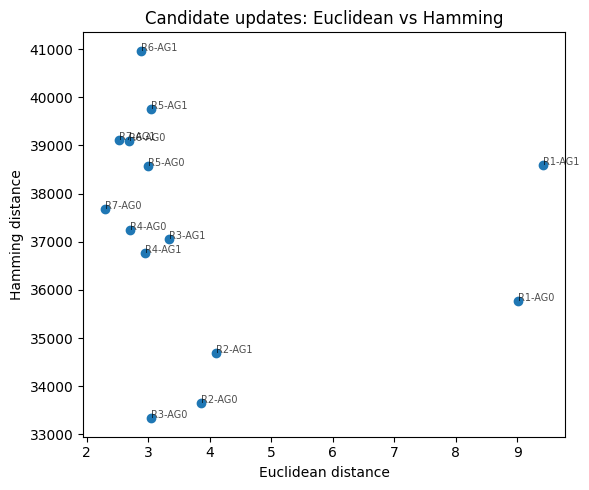

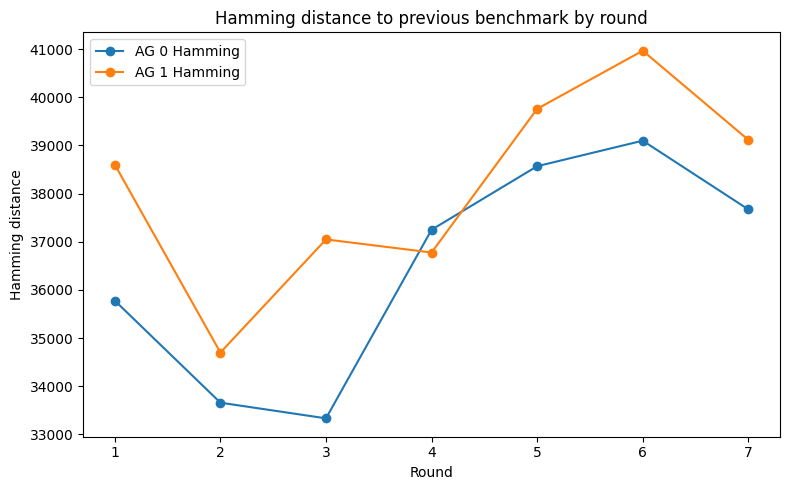

In [13]:
plt.figure(figsize=(6,5))
plt.scatter(results_df["euclidean_distance"],results_df["hamming_distance"])
for _,row in results_df.iterrows():
    plt.annotate(f"R{int(row['round'])}-AG{int(row['candidate_ag'])}",(row["euclidean_distance"],row["hamming_distance"]),fontsize=7,alpha=0.7)
plt.xlabel("Euclidean distance")
plt.ylabel("Hamming distance")
plt.title("Candidate updates: Euclidean vs Hamming")
plt.tight_layout()
plt.savefig(FIGURES_DIR/"euclidean_vs_hamming.png",dpi=300,bbox_inches="tight")
plt.show()

plt.figure(figsize=(8,5))
for ag_id in AG_IDS:
    subset=results_df[results_df["candidate_ag"]==ag_id]
    plt.plot(subset["round"],subset["hamming_distance"],marker="o",label=f"AG {ag_id} Hamming")
plt.xlabel("Round")
plt.ylabel("Hamming distance")
plt.title("Hamming distance to previous benchmark by round")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR/"hamming_by_round.png",dpi=300,bbox_inches="tight")
plt.show()

## Save reproducible outputs

In [14]:
results_df.to_csv(RESULTS_DIR/"candidate_benchmark_distances.csv",index=False)
ranking_df.to_csv(RESULTS_DIR/"winner_agreement.csv",index=False)

print("Saved:")
for path in [
    RESULTS_DIR/"candidate_benchmark_distances.csv",
    RESULTS_DIR/"winner_agreement.csv",
    RESULTS_DIR/"correlation_summary.csv",
    FIGURES_DIR/"euclidean_vs_hamming.png",
    FIGURES_DIR/"hamming_by_round.png"
]:
    print(" -",path)

Saved:
 - results/candidate_benchmark_distances.csv
 - results/winner_agreement.csv
 - results/correlation_summary.csv
 - results/figures/euclidean_vs_hamming.png
 - results/figures/hamming_by_round.png


## Interpretation and reproducibility notes

This experiment measures the relationship between LSHFed's Hamming distance and full Euclidean distance **for trainable parameter updates generated during federated training**. But it shouldn't be interpreted as proving that Hamming universally approximates Euclidean distance.